# ICFERST Geothermal Simulation – Results Processing

## *Note that this is not yet finished*

### For the data you will either need to download from virtual machine yourself or clone from hugging face: 
```bash
cd <this directory>
git clone https://huggingface.co/datasets/Jamie1701/ICFERST
```

In this notebook we load `model_outfluxes.csv` files produced by IC-FERST and plot temperature
evolution over time, stratified by phase and well surface.

## Phases

| Phase | Meaning |
|-------|---------|
| **Phase 1** | Whole-reservoir temperature evolution (native groundwater; represents bulk thermal response) |
| **Phase 2** | Well surface outflux temperature (injected working fluid at each well; represents the active fluid returning to surface) |

## Surfaces (well locations)

| Surface | Well role |
|---------|----------|
| **S101** | Warm well (produces during heating season; injects during cooling season) |
| **S102** | Cold well (injects during heating season; produces during cooling season) |

Four superimposed sensitivity plots are generated (one per `phase × surface` combination).
All runs listed in `SIMULATIONS` are overlaid on each plot for easy comparison of thermal responses under different parameter sensitivities.

In [233]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import os

warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)

In [234]:
# OUT_DIR: root of all simulation output subdirectories.
OUT_DIR = Path("/Users/jamiepersonal/Documents/IMPERIAL/GEOTHERMAL/ICFERST_results/ICFERST/ICFERST/OUT")
# DYNAMIC_OUT_DIR = os.path.join(os.getcwd(), "ICFERST/OUT") # Use this if running project form your own machine but you may want to change. 

# SIMULATIONS: list of (relative_path_from_OUT_DIR, display_label) tuples.
#
# To add a new run: add a new tuple, e.g.
#   ("Xinzhe/capacity_higher/base_scenario_1/model_outfluxes.csv", "High capacity"),
#
# To temporarily exclude a run: comment out its line.
# Labels appear directly in the plot legend, so keep them concise.
SIMULATIONS = [
    # Indah
    ("indah/model_outfluxes.csv",
     "Base"),
    ("indah/fracture-model/fracture-model_outfluxes.csv",
     "Fracture"),

    # Edu
    ("Edu/Permeabiliy2/High/model_outfluxes.csv",
     "High permeability"),
    ("Edu/Permeabiliy2/Low/model_outfluxes.csv",
     "Low permeability"),
    ("Edu/Scenario2/model_outfluxes.csv",
     "Scenario 2"),

    # Meixuan
    ("Meixuan/capa1/model_outfluxes.csv",
     "Low specific heat capacity"),
    ("Meixuan/capa2/model_outfluxes.csv",
     "High specific heat capacity"),
    ("low_porosity_model_outfluxes.csv",
     "Low porosity"),
    ("Meixuan/poro2/model_outfluxes.csv",
     "High porosity"),

    # Boundary condition sensitivity
    ("bondcond_higher_model_outfluxes.csv",
     "Boundary condition – Higher"),
    ("bondcond_lower_model_outfluxes.csv",
     "Boundary condition – Lower"),

    # Coupled fracture sensitivity
    ("coupledfracture_higher_model_outfluxes.csv",
     "Coupled fracture – Higher"),
    ("coupledfracture_lower_model_outfluxes.csv",
     "Coupled fracture – Lower"),

    # Heat conductivity sensitivity
    ("heat_cond_up_model_outfluxes.csv",
     "Heat conductivity – Higher"),
    ("heat_cond_down_model_outfluxes.csv",
     "Heat conductivity – Lower"),

    # Well swap scenario
    ("well_swap_model_outfluxes.csv",
     "Well swap"),
]

# COLUMNS OF INTEREST
# Time axis (x).
TIME_COL = "Time[y]"

# Temperature columns to plot (y).  Each entry produces one independent figure.
# Tuple layout: (column_name, figure_title, y_axis_label)
#
# PHASE 1: bulk reservoir temperature (native groundwater) – represents how the
#          entire formation's thermal state evolves over the simulation period.
#
# PHASE 2: well surface outflux temperature (injected working fluid) – represents
#          the temperature of the active fluid returning at each well surface.
#
# S101 = warm well surface;  S102 = cold well surface.
PLOT_SPECS = [
    (
        "phase1[S101]AVG(Temperature)",
        "Reservoir Temperature at Warm Well (S101) – Phase 1 | Time Series",
        "Average Temperature [°C]",
    ),
    (
        "phase1[S102]AVG(Temperature)",
        "Reservoir Temperature at Cold Well (S102) – Phase 1 | Time Series",
        "Average Temperature [°C]",
    ),
    (
        "phase2[S101]AVG(Temperature)",
        "Well Outflux Temperature at Warm Well (S101) – Phase 2 | Time Series",
        "Average Temperature [°C]",
    ),
    (
        "phase2[S102]AVG(Temperature)",
        "Well Outflux Temperature at Cold Well (S102) – Phase 2 | Time Series",
        "Average Temperature [°C]",
    ),
]

In [235]:
# Data loading functions

def load_outflux(csv_path: Path) -> pd.DataFrame:
    """
    Read an IC-FERST outfluxes CSV into a DataFrame.

    The files use leading/trailing whitespace in both header names and values;
    skipinitialspace=True and str.strip() clean those up.  Rows that repeat
    the header (a quirk seen in some outputs) are dropped automatically.
    """
    df = pd.read_csv(csv_path, skipinitialspace=True)
    # Strip any residual whitespace from column names.
    df.columns = df.columns.str.strip()
    # Drop rows that are a repeated header line (value == column name).
    df = df[df[TIME_COL] != TIME_COL]
    # Convert all columns to numeric; non-numeric cells (e.g. 'NaN') become NaN.
    df = df.apply(pd.to_numeric, errors="coerce")
    return df


def load_all_simulations(
    simulations: list[tuple[str, str]],
    out_dir: Path,
) -> list[tuple[str, pd.DataFrame]]:
    """
    Load all simulation CSVs listed in `simulations`.

    Returns a list of (label, DataFrame) pairs, skipping any file that is
    missing (with a printed warning) so partial result sets don't crash the
    notebook.
    """
    loaded = []
    for rel_path, label in simulations:
        full_path = out_dir / rel_path
        if not full_path.exists():
            print(f"[WARNING] File not found, skipping: {full_path}")
            continue
        df = load_outflux(full_path)
        loaded.append((label, df))
        print(f"[OK] Loaded {len(df):>5} rows  -  {label}")
    return loaded


# Load everything now so plots can share the same in-memory data.
datasets = load_all_simulations(SIMULATIONS, OUT_DIR)
print(f"\n{len(datasets)} simulation(s) loaded successfully.")

[OK] Loaded  1200 rows  -  Base
[OK] Loaded  1200 rows  -  Fracture
[OK] Loaded  1200 rows  -  High permeability
[OK] Loaded  1200 rows  -  Low permeability
[OK] Loaded  1200 rows  -  Scenario 2
[OK] Loaded  1200 rows  -  Low specific heat capacity
[OK] Loaded  1200 rows  -  High specific heat capacity
[OK] Loaded  1200 rows  -  Low porosity
[OK] Loaded  1200 rows  -  High porosity
[OK] Loaded  1200 rows  -  Boundary condition – Higher
[OK] Loaded  1200 rows  -  Boundary condition – Lower
[OK] Loaded  1200 rows  -  Coupled fracture – Higher
[OK] Loaded  1200 rows  -  Coupled fracture – Lower
[OK] Loaded  1200 rows  -  Heat conductivity – Higher
[OK] Loaded  1200 rows  -  Heat conductivity – Lower
[OK] Loaded  1200 rows  -  Well swap

16 simulation(s) loaded successfully.


In [236]:
# PLOTTING

def plot_temperature_sensitivity(
    datasets: list[tuple[str, pd.DataFrame]],
    column: str,
    title: str,
    ylabel: str,
    time_col: str = TIME_COL,
    figsize: tuple[float, float] = (12, 5),
    save_path: Path | None = None,
    legend_loc = None,
) -> None:
    """
    Produce one time-series figure with all simulation runs superimposed.

    Parameters
    ----------
    datasets   : list of (label, DataFrame) from load_all_simulations().
    column     : outflux CSV column to plot on the y-axis.
    title      : figure title string.
    ylabel     : y-axis label string.
    time_col   : name of the time column (default TIME_COL = "Time[y]").
    figsize    : matplotlib figure size in inches (width, height).
    save_path  : if provided, the figure is saved to this path as well as shown.
                 Pass e.g. Path("figures/phase1_S101.png") to persist plots.
    """
    fig, ax = plt.subplots(figsize=figsize)

    plotted = 0
    for label, df in datasets:
        if column not in df.columns:
            print(f"  [WARNING] Column '{column}' not found in dataset '{label}' – skipping.")
            continue
        series = df[column].dropna()
        if series.empty:
            print(f"  [WARNING] Column '{column}' is all-NaN in dataset '{label}' – skipping.")
            continue
        ax.plot(df.loc[series.index, time_col], series, label=label, linewidth=1.5)
        plotted += 1

    if plotted == 0:
        print(f"No data to plot for column '{column}'.")
        plt.close(fig)
        return

    ax.set_xlabel("Time [years]", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    if legend_loc is not None:
        ax.legend(fontsize=9, loc=legend_loc, framealpha=0.8)
    else:
        ax.legend(fontsize=9, loc="best", framealpha=0.8)
    ax.grid(True, linestyle="--", alpha=0.5)
    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Figure saved → {save_path}")

    plt.show()

  Figure saved → figures/phase1_S101AVGTemperature.png


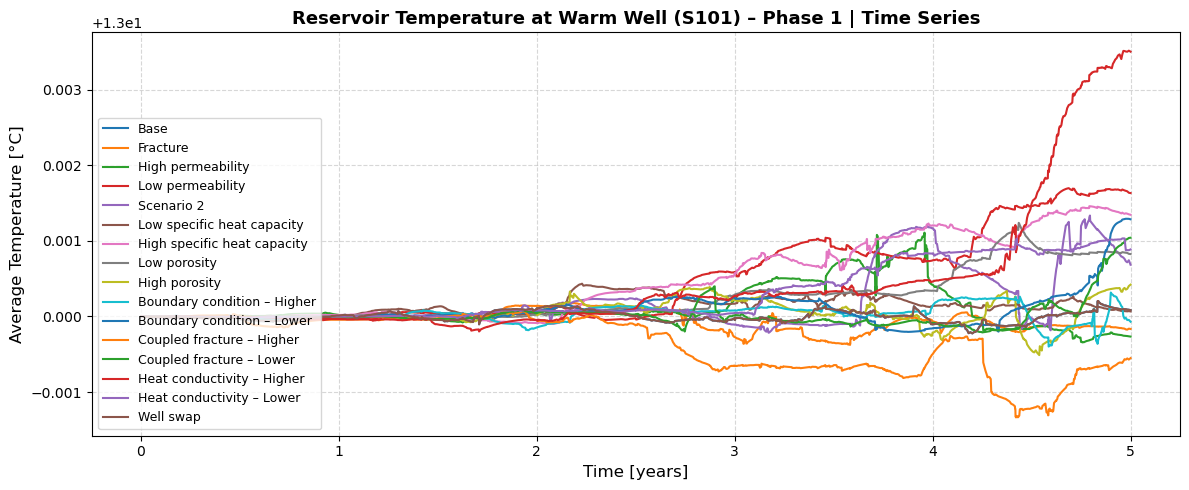

  Figure saved → figures/phase1_S102AVGTemperature.png


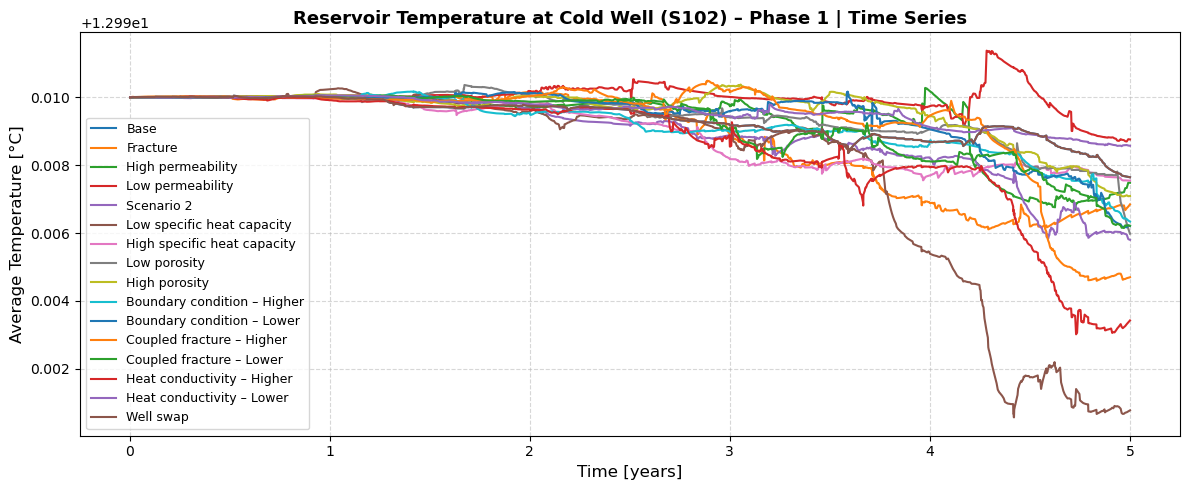

  Figure saved → figures/phase2_S101AVGTemperature.png


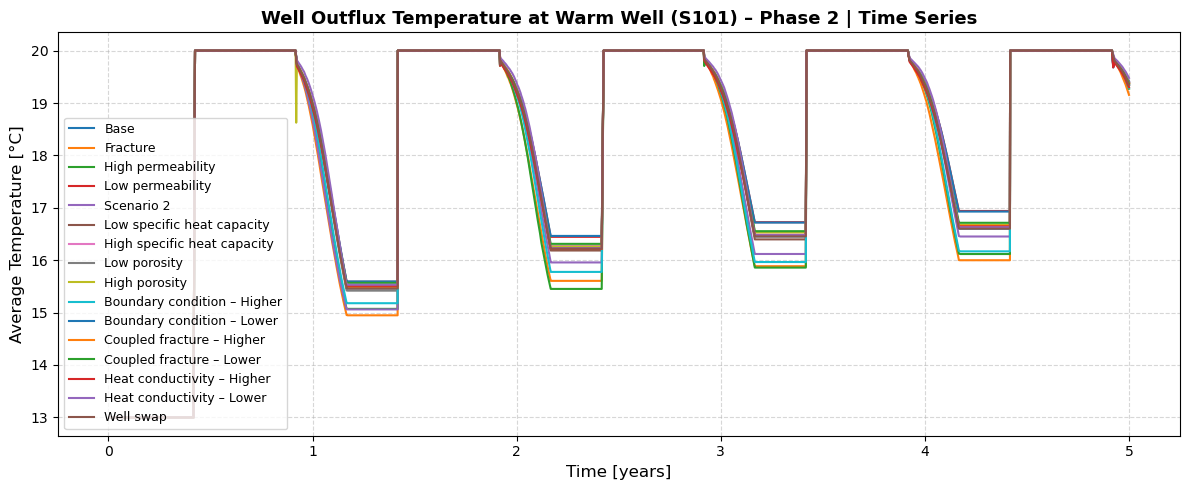

  Figure saved → figures/phase2_S102AVGTemperature.png


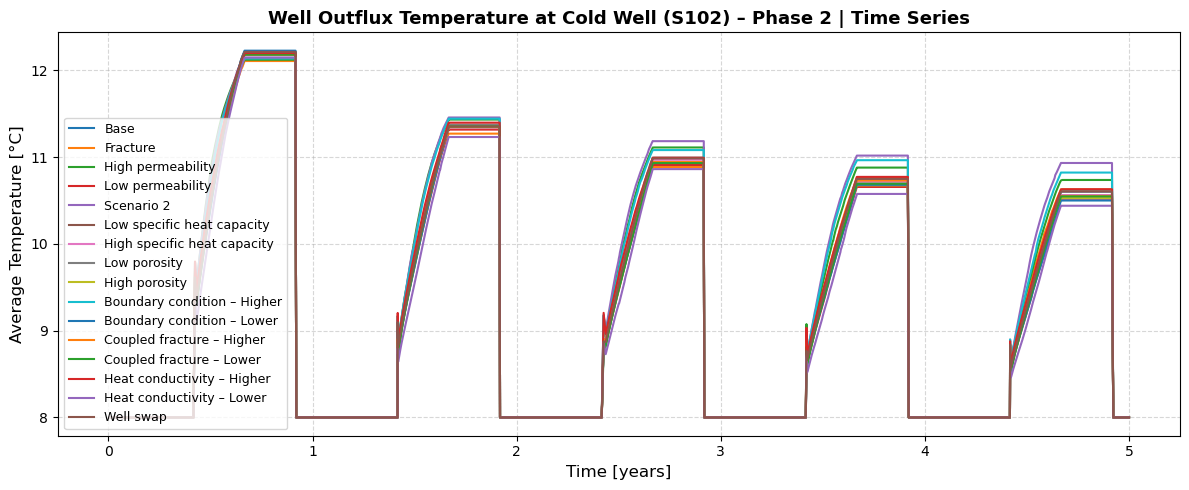

In [237]:
# GENERATE ALL SENSITIVITY PLOTS

# Iterates over PLOT_SPECS defined in the configuration cell above.
# To save figures to disk, set SAVE_FIGURES = True and adjust FIGURES_DIR.

SAVE_FIGURES = True
FIGURES_DIR = Path("figures")  # relative to the notebook location

for col, title, ylabel in PLOT_SPECS:
    save_path = (FIGURES_DIR / f"{col.replace('[', '_').replace(']', '').replace('(', '').replace(')', '')}.png"
                 if SAVE_FIGURES else None)
    plot_temperature_sensitivity(
        datasets=datasets,
        column=col,
        title=title,
        ylabel=ylabel,
        save_path=save_path,
        legend_loc="lower left"
    )

In [238]:
# ─────────────────────────────────────────────────────────────────────────────
# SENSITIVITY ANALYSIS CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
# Map each sensitivity group to (baseline_label, [variation_label, ...])
# The baseline is the reference; variations show deviation from it.
# Labels must match exactly those in SIMULATIONS.
#
# To add a new sensitivity group: append a new tuple, e.g.
#   ("Xinzhe – Capacity", "Base", ["High capacity"]),
#
# If a sensitivity has no clear baseline, use the first listed case as reference.
SENSITIVITY_GROUPS = [
    ("Fracture Effect", "Base", ["Fracture"]),
    ("Permeability Sensitivity", "Base", ["High permeability", "Low permeability"]),
    ("Scenario Variation", "Base", ["Scenario 2"]),
    ("Porosity Sensitivity", "Low porosity", ["High porosity"]),
    ("Capacity Sensitivity", "Low specific heat capacity", ["High specific heat capacity"]),
]

In [239]:
import numpy as np

def tornado_chart(labels, midpoint, low_values, high_values,
                  title="Sensitivity Analysis", save_path=None):
    """Simple tornado chart — one fresh figure per call."""
    color_low  = '#e1ceff'
    color_high = '#ff6262'

    plt.figure(figsize=(12, max(4, len(labels) * 0.8)))
    ys = range(len(labels))
    # Note this computes based on absolute drift from initial value with respect to each regime
    for y, low_value, high_value in zip(ys, low_values, high_values):
        low_width  = midpoint - low_value
        high_width = high_value - midpoint

        plt.broken_barh(
            [(low_value, low_width), (midpoint, high_width)],
            (y - 0.4, 0.8),
            facecolors=[color_low, color_high],
            edgecolors=['black', 'black'],
            linewidth=0.5
        )

    plt.axvline(midpoint, color='black', linewidth=1)

    ax = plt.gca()
    ax.spines[['right', 'left', 'top']].set_visible(False)

    plt.xlabel('RMS Temperature Deviation [°C]')
    plt.yticks(ys, labels)
    plt.ylim(-0.5, len(labels) - 0.5)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.tick_params(left=False)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Saved → {save_path}")

    plt.show()


phase1[S101]AVG(Temperature)
  Base: 0.0001°C
  Fracture: 0.0001°C
  High permeability: 0.0003°C
  Low permeability: 0.0008°C
  Scenario 2: 0.0005°C
  Low specific heat capacity: 0.0002°C
  High specific heat capacity: 0.0007°C
  Low porosity: 0.0004°C
  High porosity: 0.0002°C
  Boundary condition – Higher: 0.0001°C
  Boundary condition – Lower: 0.0002°C
  Coupled fracture – Higher: 0.0005°C
  Coupled fracture – Lower: 0.0002°C
  Heat conductivity – Higher: 0.0010°C
  Heat conductivity – Lower: 0.0005°C
  Well swap: 0.0001°C
  Saved → figures/tornado_phase1_S101AVGTemperature.png


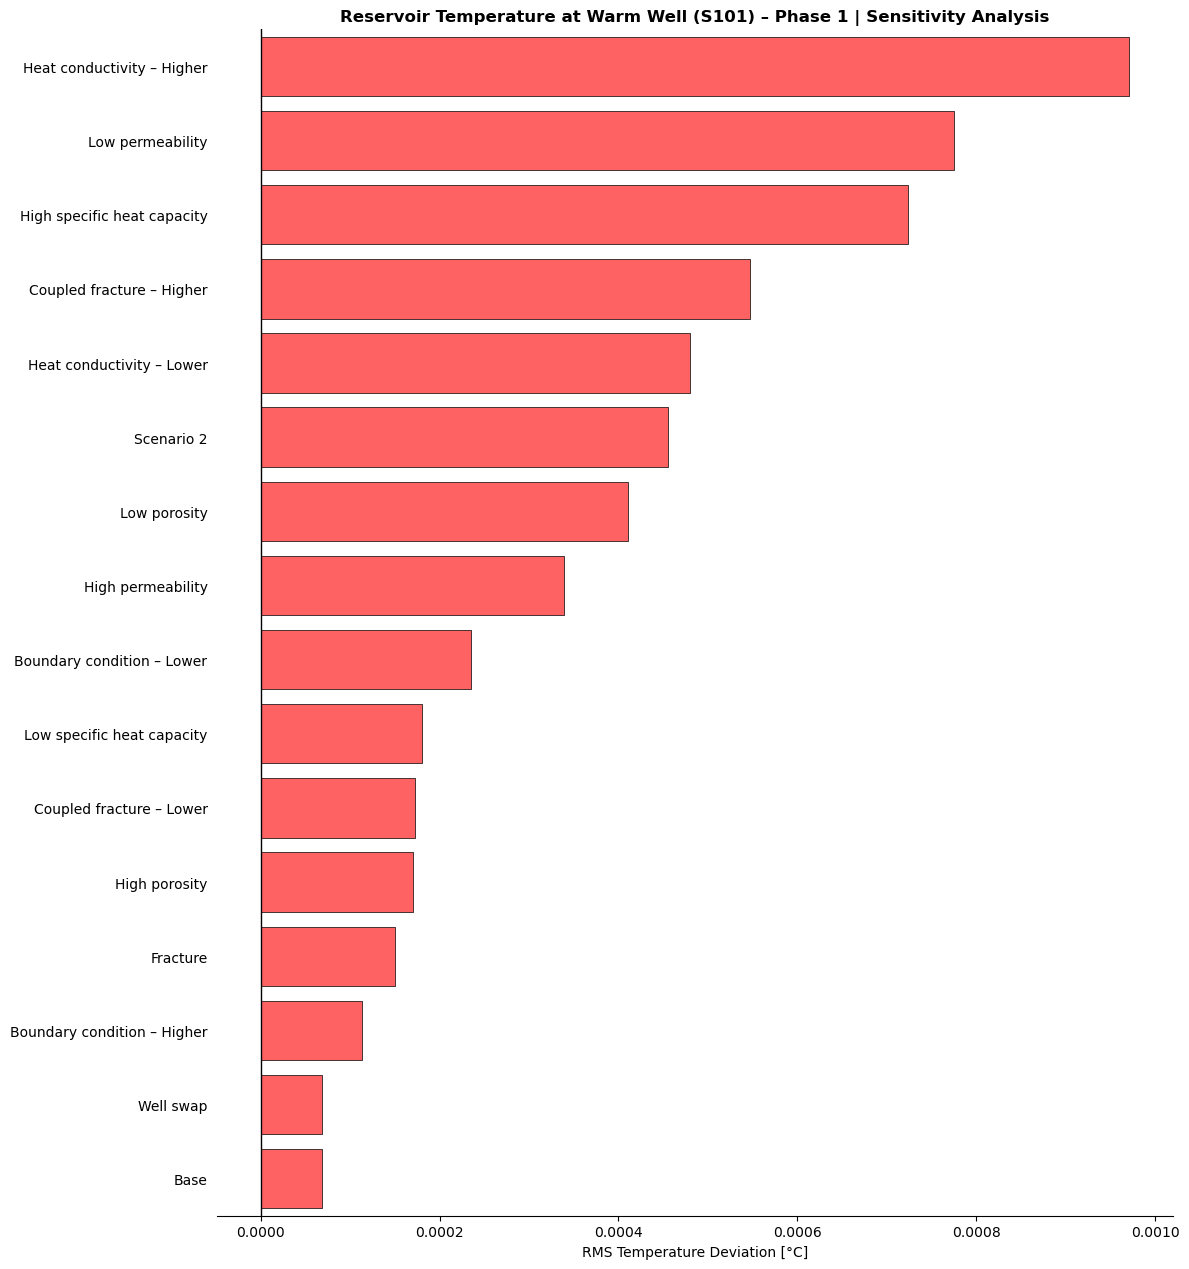


phase1[S102]AVG(Temperature)
  Base: 0.0009°C
  Fracture: 0.0019°C
  High permeability: 0.0012°C
  Low permeability: 0.0004°C
  Scenario 2: 0.0016°C
  Low specific heat capacity: 0.0037°C
  High specific heat capacity: 0.0014°C
  Low porosity: 0.0009°C
  High porosity: 0.0008°C
  Boundary condition – Higher: 0.0012°C
  Boundary condition – Lower: 0.0011°C
  Coupled fracture – Higher: 0.0016°C
  Coupled fracture – Lower: 0.0013°C
  Heat conductivity – Higher: 0.0024°C
  Heat conductivity – Lower: 0.0006°C
  Well swap: 0.0009°C
  Saved → figures/tornado_phase1_S102AVGTemperature.png


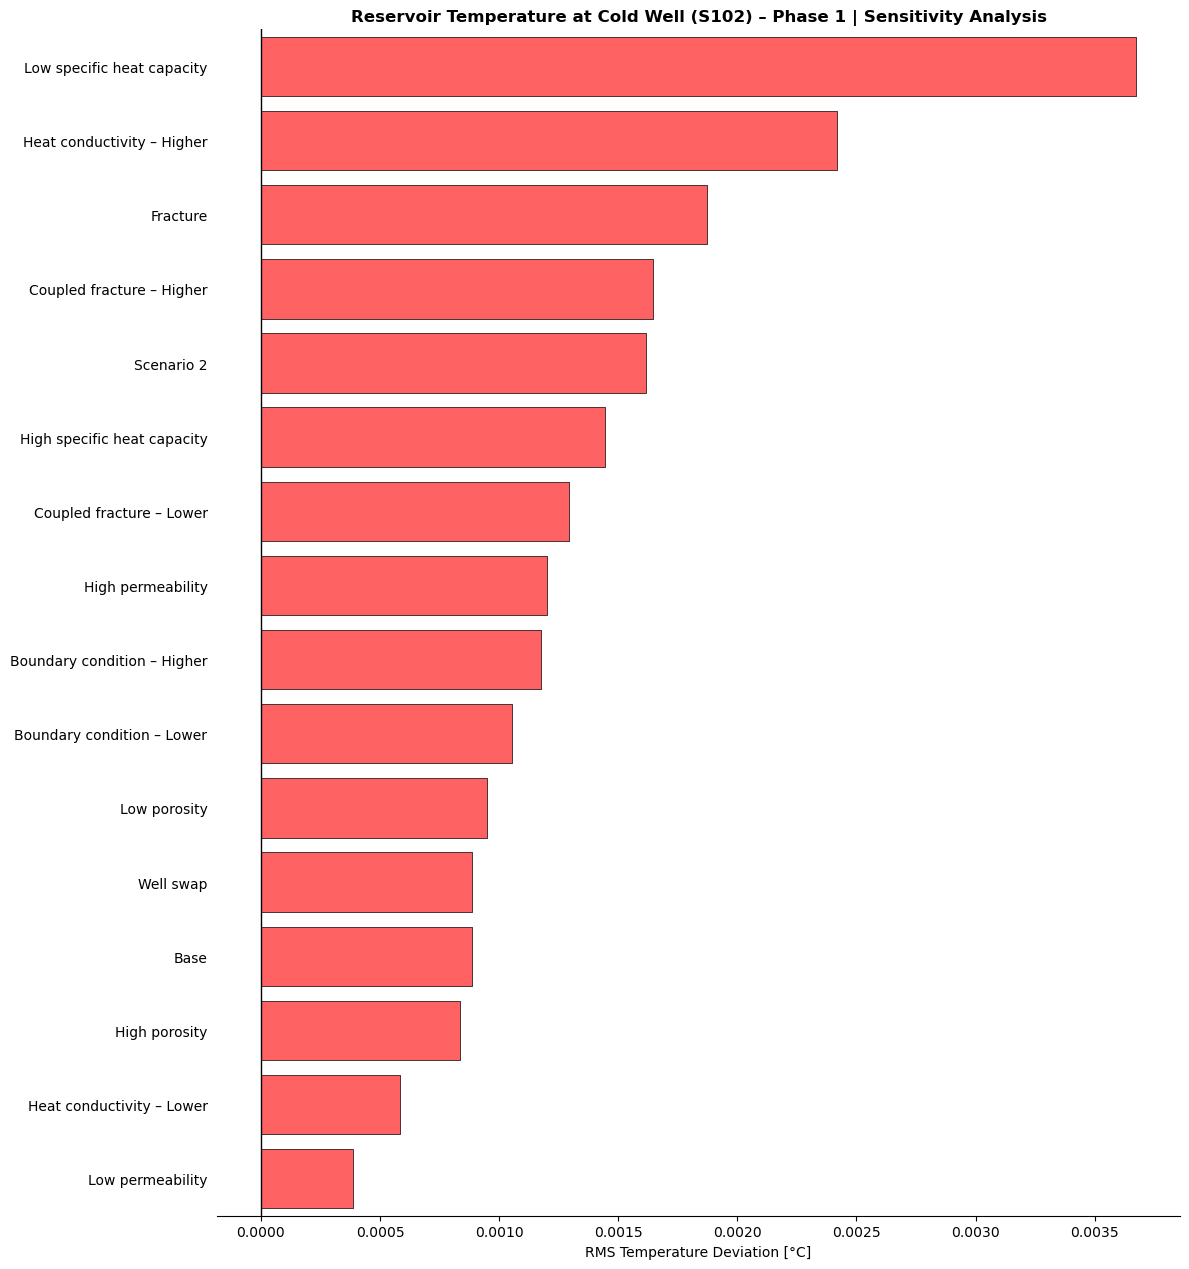


phase2[S101]AVG(Temperature)
  Base: 5.9470°C
  Fracture: 5.8462°C
  High permeability: 5.8581°C
  Low permeability: 5.9834°C
  Scenario 2: 5.9057°C
  Low specific heat capacity: 5.9440°C
  High specific heat capacity: 5.9524°C
  Low porosity: 5.9464°C
  High porosity: 5.9578°C
  Boundary condition – Higher: 5.8832°C
  Boundary condition – Lower: 5.9835°C
  Coupled fracture – Higher: 5.9531°C
  Coupled fracture – Lower: 5.9607°C
  Heat conductivity – Higher: 5.9417°C
  Heat conductivity – Lower: 5.9711°C
  Well swap: 5.9470°C
  Saved → figures/tornado_phase2_S101AVGTemperature.png


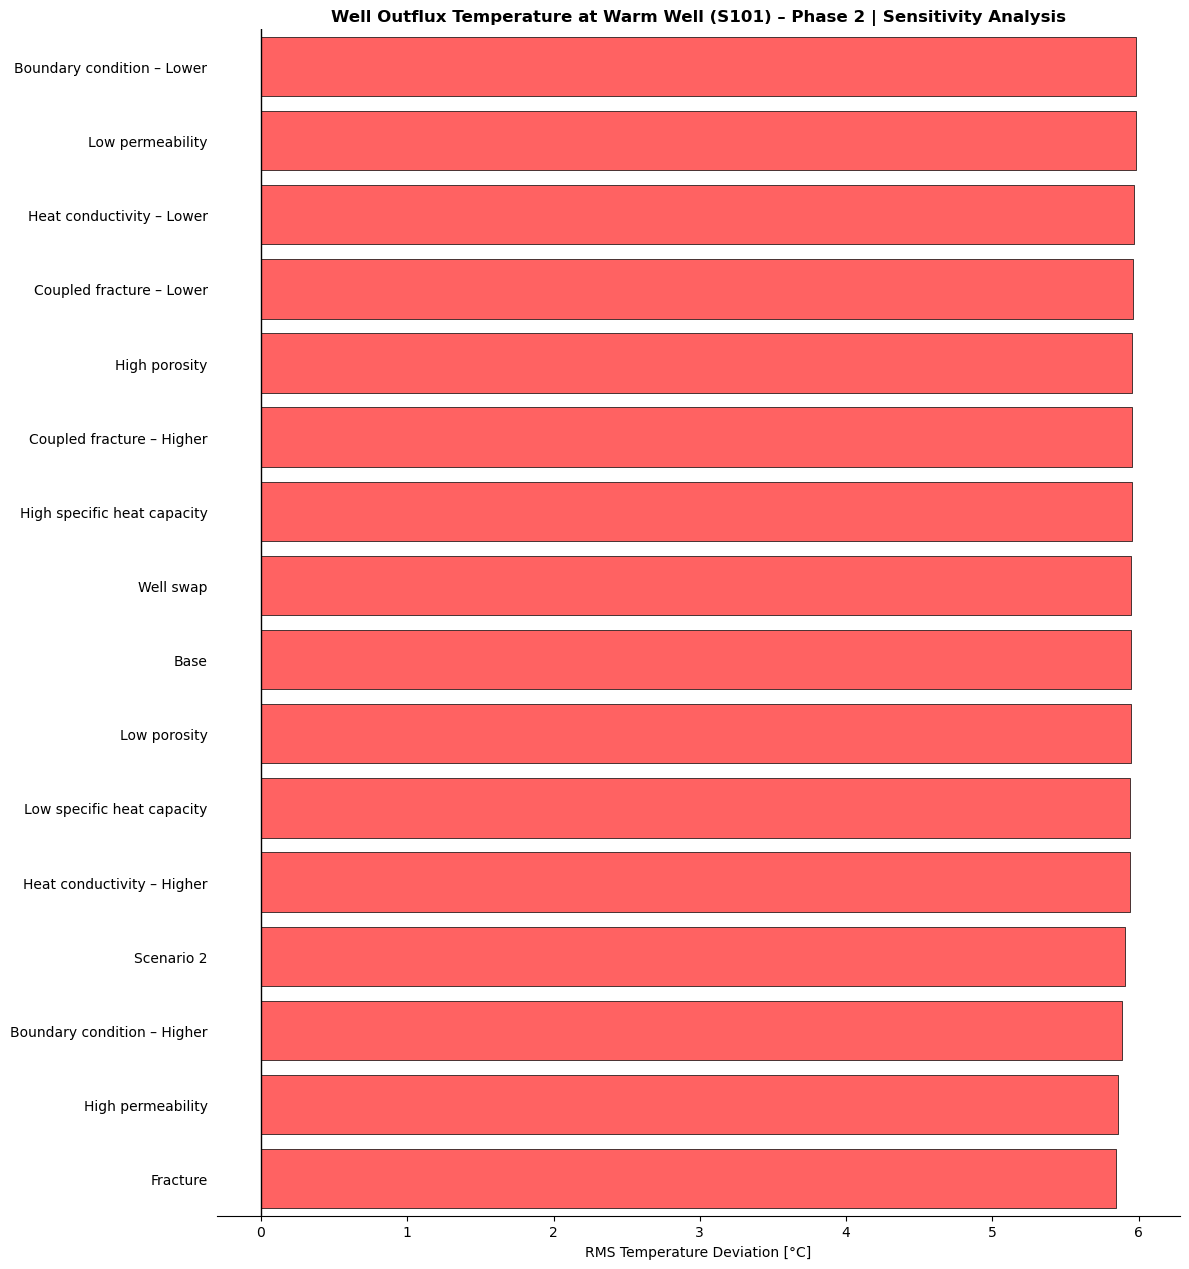


phase2[S102]AVG(Temperature)
  Base: 2.0297°C
  Fracture: 2.0136°C
  High permeability: 2.1122°C
  Low permeability: 1.9874°C
  Scenario 2: 2.1752°C
  Low specific heat capacity: 2.0229°C
  High specific heat capacity: 2.0122°C
  Low porosity: 2.0360°C
  High porosity: 2.0040°C
  Boundary condition – Higher: 2.1312°C
  Boundary condition – Lower: 1.9967°C
  Coupled fracture – Higher: 2.0161°C
  Coupled fracture – Lower: 2.0029°C
  Heat conductivity – Higher: 2.0555°C
  Heat conductivity – Lower: 1.9253°C
  Well swap: 2.0297°C
  Saved → figures/tornado_phase2_S102AVGTemperature.png


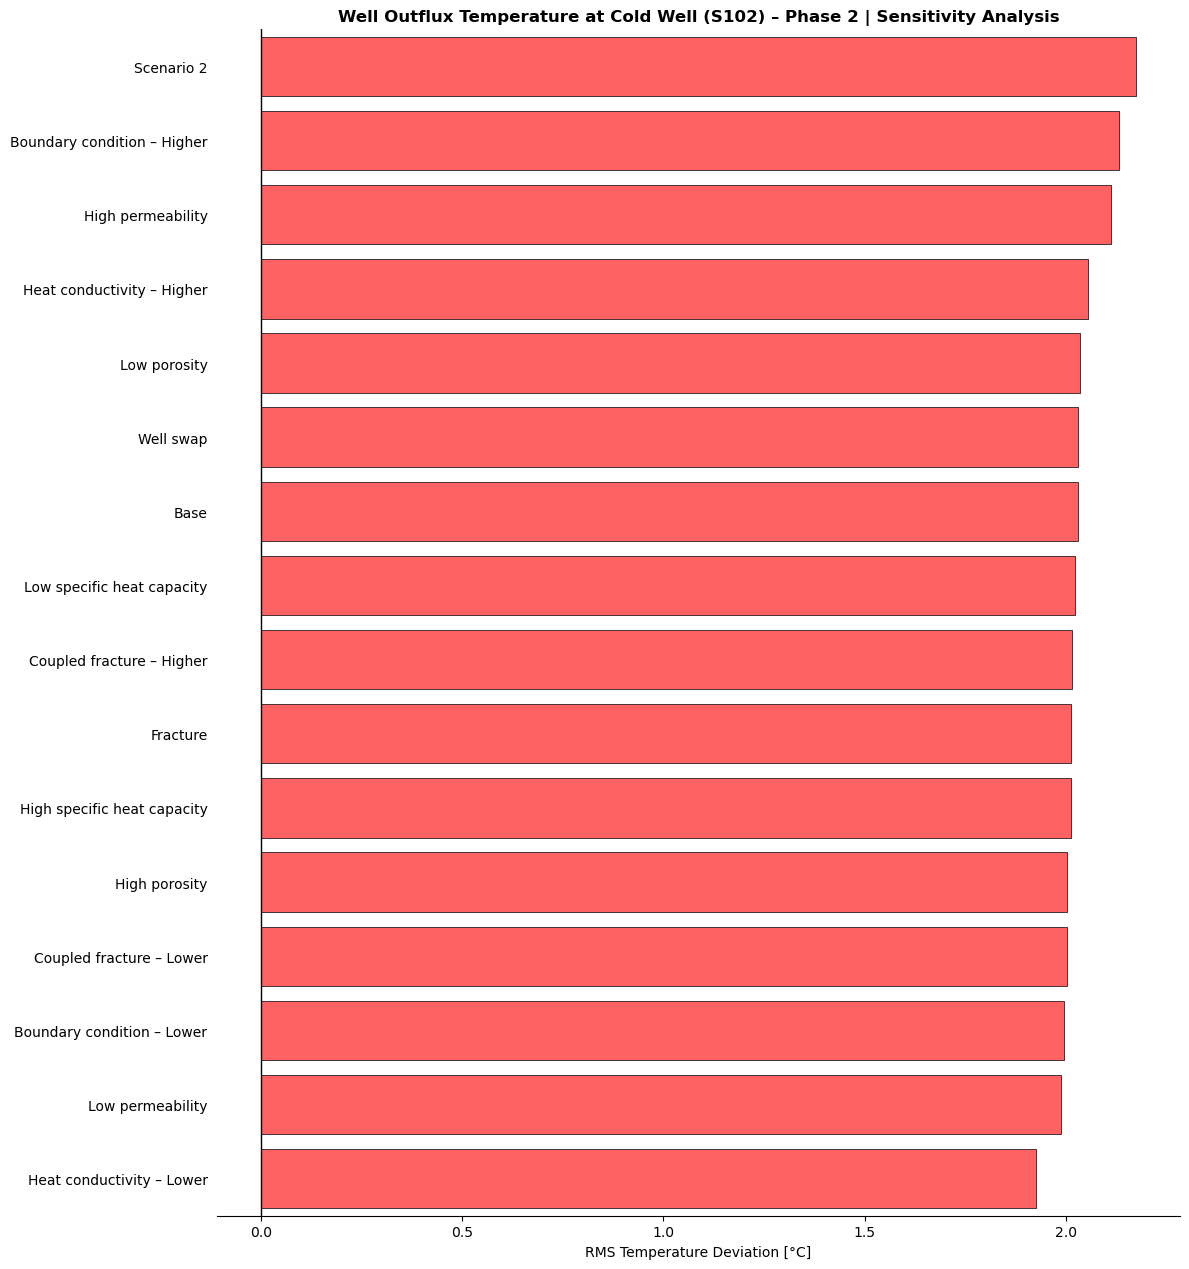

In [240]:
# ─────────────────────────────────────────────────────────────────────────────
# GENERATE TORNADO CHARTS FOR EACH TEMPERATURE COLUMN
# ─────────────────────────────────────────────────────────────────────────────
# Each simulation gets its own bar. RMS measures how much the temperature
# deviates from its own initial value over the full simulation period.

midpoint = 0.0

for col, time_series_title, ylabel in PLOT_SPECS:
    print(f"\n{'='*70}\n{col}\n{'='*70}")

    variant_rms = {}
    for label, df in datasets:
        series = df[col].dropna()
        if series.empty:
            print(f"  [SKIP] {label}: no data for {col}")
            continue
        initial_temp = series.iloc[0]
        rms = float(np.sqrt(np.mean((series - initial_temp) ** 2)))
        variant_rms[label] = rms
        print(f"  {label}: {rms:.4f}°C")

    # Sort ascending so largest bar lands at top of plot.
    sorted_variants = sorted(variant_rms.items(), key=lambda x: x[1])
    labels      = np.array([v[0] for v in sorted_variants])
    high_values = np.array([v[1] for v in sorted_variants])
    low_values  = np.zeros(len(labels))

    tornado_title = time_series_title.replace("Time Series", "Sensitivity Analysis")
    save_path = (FIGURES_DIR / f"tornado_{col.replace('[','_').replace(']','').replace('(','').replace(')','')}.png"
                 if SAVE_FIGURES else None)

    tornado_chart(
        labels=labels,
        midpoint=midpoint,
        low_values=low_values,
        high_values=high_values,
        title=tornado_title,
        save_path=save_path,
    )


phase1[S101]AVG(Temperature) – TORNADO CHART
  Base                                    : 0.0001°C
  Fracture                                : 0.0001°C
  High permeability                       : 0.0003°C
  Low permeability                        : 0.0008°C
  Scenario 2                              : 0.0005°C
  Low specific heat capacity              : 0.0002°C
  High specific heat capacity             : 0.0007°C
  Low porosity                            : 0.0004°C
  High porosity                           : 0.0002°C
  Boundary condition – Higher             : 0.0001°C
  Boundary condition – Lower              : 0.0002°C
  Coupled fracture – Higher               : 0.0005°C
  Coupled fracture – Lower                : 0.0002°C
  Heat conductivity – Higher              : 0.0010°C
  Heat conductivity – Lower               : 0.0005°C
  Well swap                               : 0.0001°C
  Saved → figures/tornado_phase1_S101AVGTemperature.png


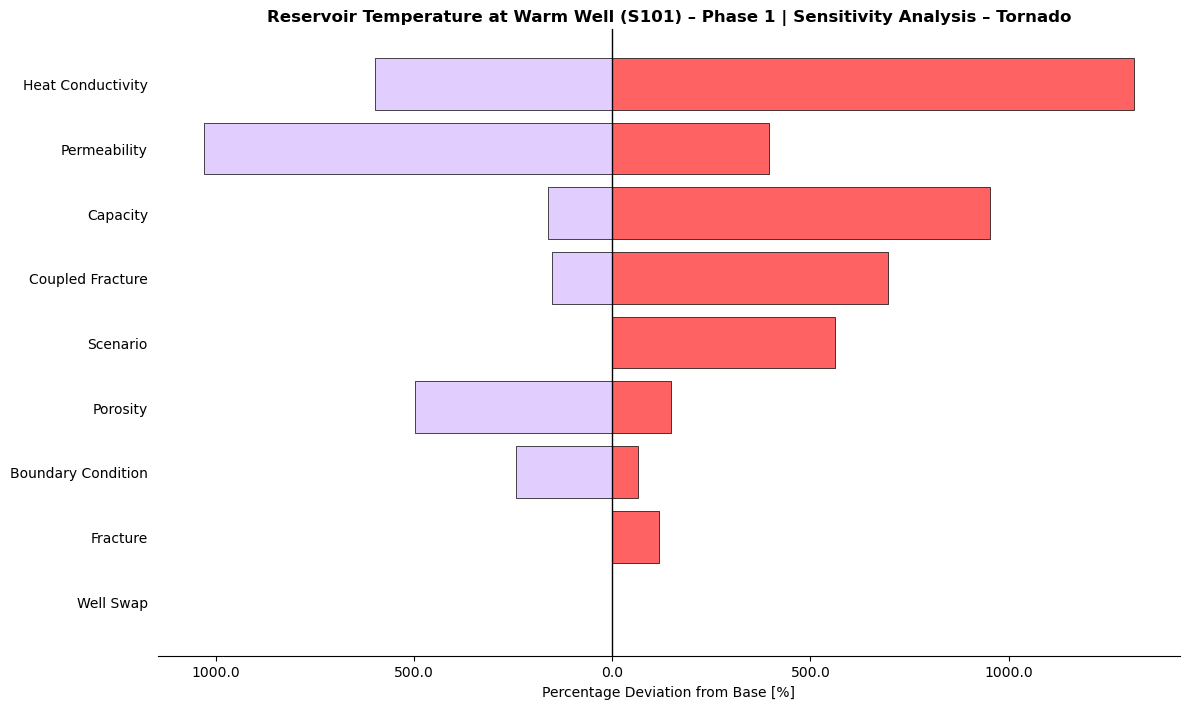


phase1[S102]AVG(Temperature) – TORNADO CHART
  Base                                    : 0.0009°C
  Fracture                                : 0.0019°C
  High permeability                       : 0.0012°C
  Low permeability                        : 0.0004°C
  Scenario 2                              : 0.0016°C
  Low specific heat capacity              : 0.0037°C
  High specific heat capacity             : 0.0014°C
  Low porosity                            : 0.0009°C
  High porosity                           : 0.0008°C
  Boundary condition – Higher             : 0.0012°C
  Boundary condition – Lower              : 0.0011°C
  Coupled fracture – Higher               : 0.0016°C
  Coupled fracture – Lower                : 0.0013°C
  Heat conductivity – Higher              : 0.0024°C
  Heat conductivity – Lower               : 0.0006°C
  Well swap                               : 0.0009°C
  Saved → figures/tornado_phase1_S102AVGTemperature.png


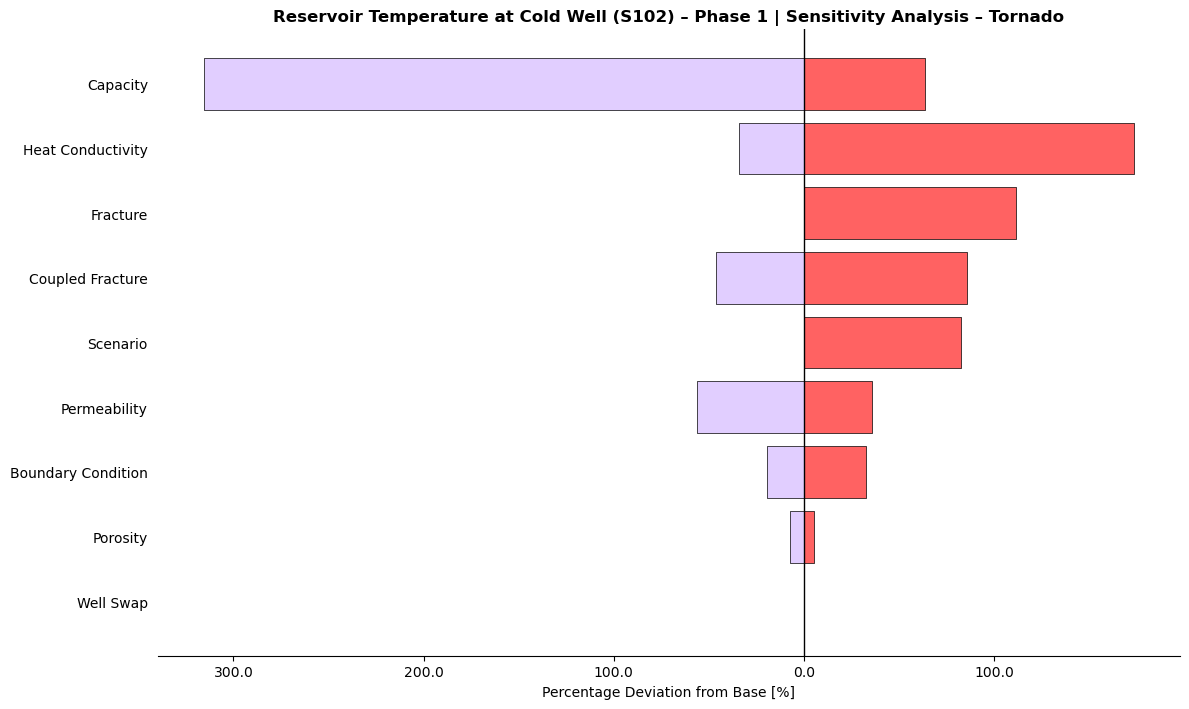


phase2[S101]AVG(Temperature) – TORNADO CHART
  Base                                    : 5.9470°C
  Fracture                                : 5.8462°C
  High permeability                       : 5.8581°C
  Low permeability                        : 5.9834°C
  Scenario 2                              : 5.9057°C
  Low specific heat capacity              : 5.9440°C
  High specific heat capacity             : 5.9524°C
  Low porosity                            : 5.9464°C
  High porosity                           : 5.9578°C
  Boundary condition – Higher             : 5.8832°C
  Boundary condition – Lower              : 5.9835°C
  Coupled fracture – Higher               : 5.9531°C
  Coupled fracture – Lower                : 5.9607°C
  Heat conductivity – Higher              : 5.9417°C
  Heat conductivity – Lower               : 5.9711°C
  Well swap                               : 5.9470°C
  Saved → figures/tornado_phase2_S101AVGTemperature.png


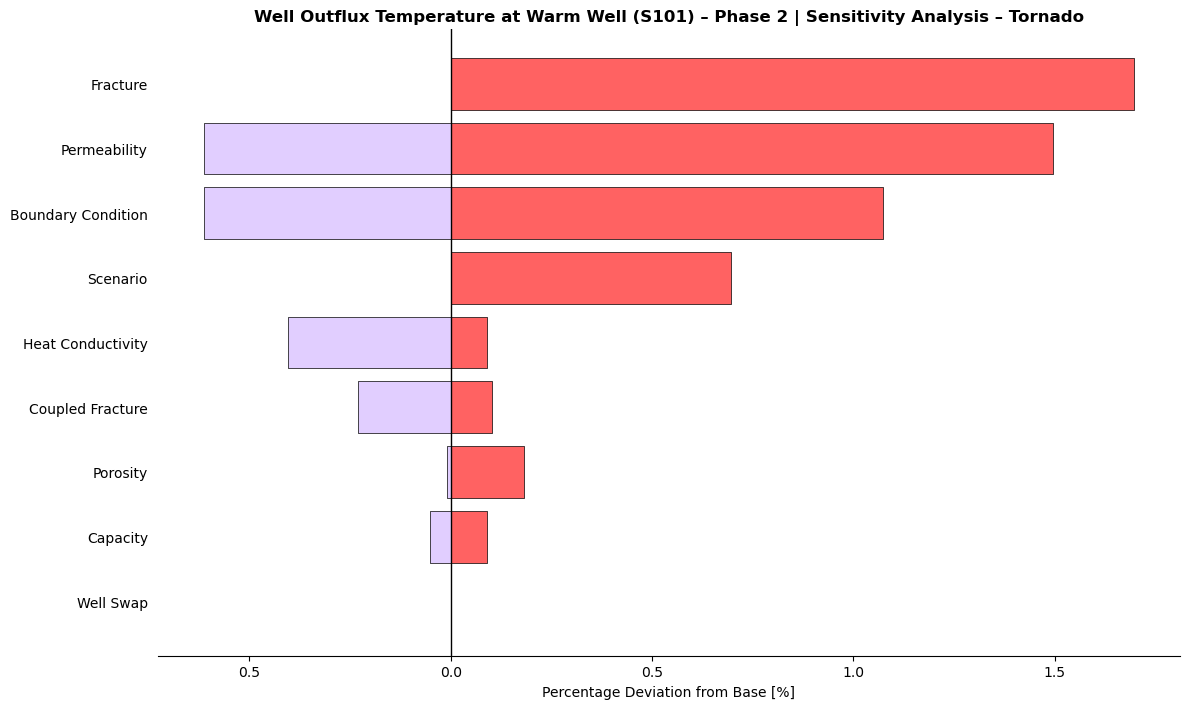


phase2[S102]AVG(Temperature) – TORNADO CHART
  Base                                    : 2.0297°C
  Fracture                                : 2.0136°C
  High permeability                       : 2.1122°C
  Low permeability                        : 1.9874°C
  Scenario 2                              : 2.1752°C
  Low specific heat capacity              : 2.0229°C
  High specific heat capacity             : 2.0122°C
  Low porosity                            : 2.0360°C
  High porosity                           : 2.0040°C
  Boundary condition – Higher             : 2.1312°C
  Boundary condition – Lower              : 1.9967°C
  Coupled fracture – Higher               : 2.0161°C
  Coupled fracture – Lower                : 2.0029°C
  Heat conductivity – Higher              : 2.0555°C
  Heat conductivity – Lower               : 1.9253°C
  Well swap                               : 2.0297°C
  Saved → figures/tornado_phase2_S102AVGTemperature.png


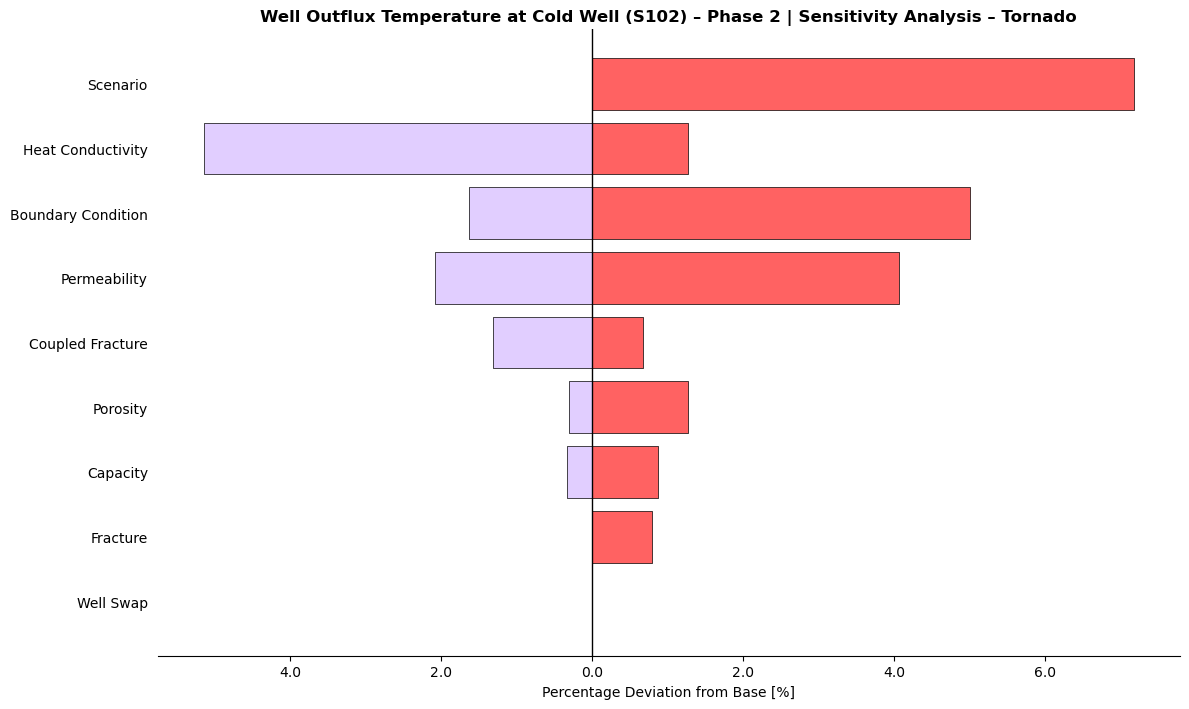

In [241]:
# ─────────────────────────────────────────────────────────────────────────────
# TORNADO CHARTS – PERCENTAGE DEVIATION FROM BASELINE, CENTERED AT 0
# ─────────────────────────────────────────────────────────────────────────────

for col, time_series_title, ylabel in PLOT_SPECS:
    print(f"\n{'='*70}\n{col} – TORNADO CHART\n{'='*70}")

    # Compute RMS for all variants
    variant_rms = {}
    for label, df in datasets:
        series = df[col].dropna()
        if series.empty:
            print(f"  [SKIP] {label}: no data")
            continue
        initial_temp = series.iloc[0]
        rms = float(np.sqrt(np.mean((series - initial_temp) ** 2)))
        variant_rms[label] = rms
        print(f"  {label:40s}: {rms:.4f}°C")

    # Get baseline RMS
    base_rms = variant_rms.get("Base", np.nan)
    
    # Define sensitivity parameters: (name, base_label, low_label, high_label)
    sensitivity_params = [
        ("Fracture", "Base", None, "Fracture"),
        ("Permeability", "Base", "Low permeability", "High permeability"),
        ("Scenario", "Base", None, "Scenario 2"),
        ("Porosity", "Base", "Low porosity", "High porosity"),
        ("Capacity", "Base", "Low specific heat capacity", "High specific heat capacity"),
        ("Boundary Condition", "Base", "Boundary condition – Lower", "Boundary condition – Higher"),
        ("Coupled Fracture", "Base", "Coupled fracture – Lower", "Coupled fracture – Higher"),
        ("Heat Conductivity", "Base", "Heat conductivity – Lower", "Heat conductivity – Higher"),
        ("Well Swap", "Base", None, "Well swap"),
    ]

    # Collect data for each parameter
    labels = []
    low_values = []
    high_values = []
    var_effects = []

    for param_name, base_label, low_label, high_label in sensitivity_params:
        base_val = variant_rms.get(base_label, np.nan)
        low_rms = variant_rms.get(low_label, base_val) if low_label else base_val
        high_rms = variant_rms.get(high_label, base_val) if high_label else base_val

        # Convert to percentage deviation from base_rms
        low_pct = ((low_rms - base_rms) / base_rms * 100) if base_rms > 0 else 0
        high_pct = ((high_rms - base_rms) / base_rms * 100) if base_rms > 0 else 0

        # If there's a low variant, reflect it as negative to project left from 0
        # If there's no low variant, keep low at 0 (only projects right)
        if low_label:
            low_pct = -abs(low_pct)
        else:
            low_pct = 0

        # High should always be positive (or 0)
        high_pct = abs(high_pct)

        effect = max(abs(low_pct), abs(high_pct))

        labels.append(param_name)
        low_values.append(low_pct)
        high_values.append(high_pct)
        var_effects.append(effect)

    # Create DataFrame and sort by effect ascending
    data = pd.DataFrame({
        'Labels': labels,
        'Low values': low_values,
        'High values': high_values,
        'Variable effect': var_effects
    })
    data = data.sort_values('Variable effect', ascending=True)

    # Plot setup
    color_low = '#e1ceff'
    color_high = '#ff6262'
    midpoint = 0.0

    fig, ax = plt.subplots(figsize=(12, max(4, len(data) * 0.8)))
    ys = range(len(data))

    # Plot bars
    for y, low_value, high_value in zip(ys, data['Low values'], data['High values']):
        low_width = midpoint - low_value
        high_width = high_value - midpoint

        ax.broken_barh(
            [(low_value, low_width), (midpoint, high_width)],
            (y - 0.4, 0.8),
            facecolors=[color_low, color_high],
            edgecolors=['black', 'black'],
            linewidth=0.5
        )

    ax.axvline(midpoint, color='black', linewidth=1)
    ax.set_yticks(ys)
    ax.set_yticklabels(data['Labels'])
    ax.set_xlabel('Percentage Deviation from Base [%]')
    ax.set_title(time_series_title.replace("Time Series", "Sensitivity Analysis – Tornado"),
                 fontsize=12, fontweight='bold')
    ax.spines[['right', 'left', 'top']].set_visible(False)
    ax.tick_params(left=False)
    
    # Format x-axis ticks to show absolute values (positive on both sides)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{abs(x):.1f}'))

    fig.tight_layout()

    if SAVE_FIGURES:
        save_path = (FIGURES_DIR / f"tornado_{col.replace('[','_').replace(']','').replace('(','').replace(')', '')}.png")
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Saved → {save_path}")

    plt.show()